# Notebook for EDA

## 1. Read in cleaned data files

In [97]:
import pandas as pd
import numpy as np
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
stadium = pd.read_csv('data/processed/clean_stadium.csv')
fanbase = pd.read_csv('data/processed/fanbase_clean.csv')
merch = pd.read_csv('data/processed/cleaned_merch.csv')
fan_merch_merged = pd.read_csv('data/processed/merch_fanbase_merged.csv')


## Missing values in Merch

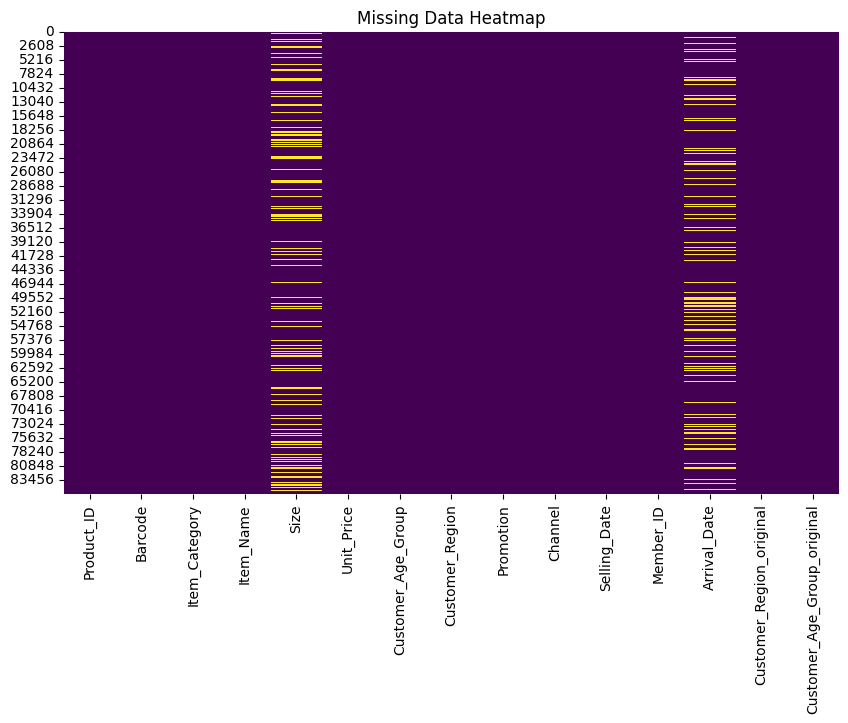

In [99]:
plt.figure(figsize=(10, 6))
sns.heatmap(merch.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

### Missing At Random (MAR): 
I already know from looking at the data that missing values in arrival date align with merch bought in store, and missing sizes align with products that do not require sizes (such as caps, mugs, posters) but this would be good to confirm.

In [100]:
data = {
    'Product' : merch['Product_ID'].unique(),
    'Item' : merch['Item_Name'].unique()
}

product_table = pd.DataFrame(data)

In [101]:
product_table

,Product,Item
0,10000000,Classic Cap
1,10000001,Retro Cap
2,10000002,Team Hoodie
3,10000003,Training Hoodie
4,10000004,Away Jersey
5,10000005,Home Jersey
6,10000006,Retro Jersey
7,10000007,Club Mug
8,10000008,Logo Mug
9,10000009,Player Poster


In [102]:
size_ids = [10000002, 10000003, 10000004, 10000005, 10000006, 10000013, 10000014, 10000015, 10000016, 10000017]

In [103]:
merch['should_have_size'] = merch['Product_ID'].isin(size_ids)

merch['size_missing'] = merch['Size'].isna()

In [104]:

merch['size_missing'] = merch['Size'].isna()

mismatches = merch[merch['should_have_size'] & merch['size_missing']]

In [105]:
mismatches.shape

(0, 17)

OK, we confirm that all missing values in the size column are due to products not needing sizes.

In [106]:
merch = merch.drop(['size_missing','should_have_size'], axis = 1)

Confirm that all missing values in arrival date are due to products being bought in store and not online:

In [107]:

merch['arrival_missing'] = merch['Arrival_Date'].isna()


merch['should_have_arrival'] = merch['Channel'] != 'Team Store'


arrival_mismatches = merch[merch['arrival_missing'] & merch['should_have_arrival']]


store_date_mismatches = merch[~merch['arrival_missing'] & (merch['Channel'] == 'Team Store')]

In [108]:
arrival_mismatches.shape

(0, 17)

In [109]:
store_date_mismatches.shape

(0, 17)

In [110]:
merch = merch.drop(['arrival_missing', 'should_have_arrival'], axis = 1)

In [111]:
merch.head()

,Product_ID,Barcode,Item_Category,Item_Name,Size,Unit_Price,Customer_Age_Group,Customer_Region,Promotion,Channel,Selling_Date,Member_ID,Arrival_Date,Customer_Region_original,Customer_Age_Group_original
0,10000000,20000000,Cap,Classic Cap,NaN,35,18–25,Domestic,False,Online,2024-02-14 09:30:00,10008632,2024-02-22 13:49:00,Domestic,18–25
1,10000000,20000001,Cap,Classic Cap,NaN,35,26–40,Domestic,False,Team Store,2024-01-31 14:30:00,10005467,NaN,Domestic,26–40
2,10000000,20000002,Cap,Classic Cap,NaN,35,18–25,Domestic,False,Team Store,2024-04-30 18:57:00,10026081,NaN,Domestic,18–25
3,10000000,20000003,Cap,Classic Cap,NaN,35,<18,Domestic,True,Online,2024-02-01 18:25:00,10005726,2024-02-09 12:35:00,Domestic,<18
4,10000000,20000004,Cap,Classic Cap,NaN,35,<18,International,False,Team Store,2024-11-24 14:07:00,10042598,NaN,International,<18
